# Posterior Predictive Checks and Residual Diagnostics

This notebook evaluates whether the fitted Bayesian MMM can reproduce the observed revenue patterns after confirming that the MCMC sampler explored the posterior reliably.

Sampler diagnostics evaluate the quality of posterior sampling, while posterior predictive checks evaluate the adequacy of the statistical model.

In [1]:
from pathlib import Path

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from pymc_marketing.mmm.multidimensional import MMM

RANDOM_SEED = 20260801

MODEL_PATH = Path(
    "../artifacts/mmm_regularized.nc"
)

train_df = pd.read_csv(
    "../data/scenario_a/scenario_a_train.csv",
    parse_dates=["date_week"],
)

channel_columns = [
    "tv_spend",
    "google_search_spend",
    "tiktok_spend",
]

control_columns = [
    "promotion",
    "time_index",
]

X_train = train_df[
    [
        "date_week",
        *channel_columns,
        *control_columns,
    ]
].copy()

y_train = train_df["revenue"].copy()

mmm_regularized = MMM.load(MODEL_PATH)

print(mmm_regularized)
print(mmm_regularized.idata.groups())

['posterior', 'sample_stats', 'prior', 'prior_predictive', 'observed_data', 'constant_data', 'fit_data']


In [2]:
posterior_predictive = (
    mmm_regularized.sample_posterior_predictive(
        X=X_train,
        extend_idata=True,
        combined=True,
        random_seed=RANDOM_SEED,
    )
)

print(posterior_predictive)

print(
    "\nInferenceData groups:",
    mmm_regularized.idata.groups(),
)

print(
    "\nPosterior predictive variables:",
    list(
        mmm_regularized
        .idata["posterior_predictive"]
        .data_vars
    ),
)

Sampling: [y]


Output()

<xarray.Dataset> Size: 4MB
Dimensions:  (date: 130, sample: 4000)
Coordinates:
  * date     (date) datetime64[us] 1kB 2023-01-02 2023-01-09 ... 2025-06-23
  * sample   (sample) object 32kB MultiIndex
  * chain    (sample) int64 32kB 0 0 0 0 0 0 0 0 0 0 0 ... 3 3 3 3 3 3 3 3 3 3 3
  * draw     (sample) int64 32kB 0 1 2 3 4 5 6 7 ... 993 994 995 996 997 998 999
Data variables:
    y        (date, sample) float64 4MB 0.8253 0.8351 0.81 ... 0.8473 0.9063
Attributes:
    created_at:                 2026-08-02T04:49:58.294308+00:00
    arviz_version:              0.23.4
    inference_library:          pymc
    inference_library_version:  5.28.1

InferenceData groups: ['posterior', 'sample_stats', 'prior', 'prior_predictive', 'observed_data', 'constant_data', 'fit_data', 'posterior_predictive', 'posterior_predictive_constant_data']

Posterior predictive variables: ['y']


In [3]:
mmm_regularized.idata["posterior_predictive"]

<xarray.Dataset> Size: 4MB
Dimensions:  (chain: 4, draw: 1000, date: 130)
Coordinates:
  * chain    (chain) int64 32B 0 1 2 3
  * draw     (draw) int64 8kB 0 1 2 3 4 5 6 7 ... 993 994 995 996 997 998 999
  * date     (date) datetime64[us] 1kB 2023-01-02 2023-01-09 ... 2025-06-23
Data variables:
    y        (chain, draw, date) float64 4MB 0.8253 0.8525 ... 0.8804 0.9063
Attributes:
    created_at:                 2026-08-02T04:49:58.294308+00:00
    arviz_version:              0.23.4
    inference_library:          pymc
    inference_library_version:  5.28.1

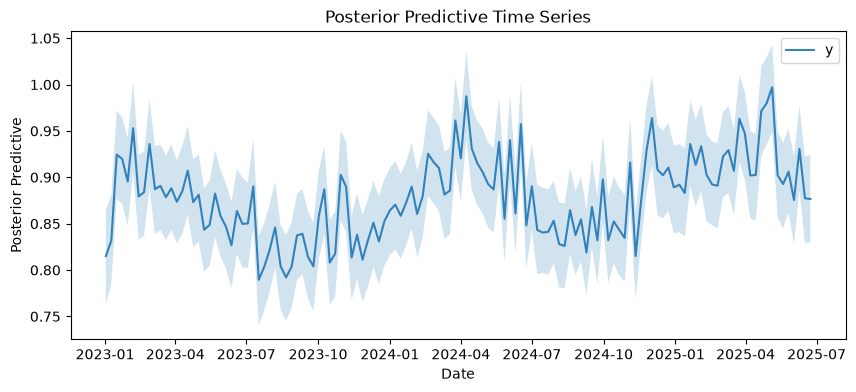

In [8]:
fig, axes = (
    mmm_regularized
    .plot
    .posterior_predictive(
        hdi_prob=0.94,
    )
)

plt.show()

In [12]:
ppc = mmm_regularized.idata.posterior_predictive["y"]

observed = y_train.to_numpy()

# Default MaxAbs target scale
target_scale = np.max(np.abs(observed))

# Verify that this is the scaling used by the fitted model
observed_scaled_model = (
    mmm_regularized
    .idata
    .observed_data["y"]
    .values
    .squeeze()
)

observed_scaled_expected = observed / target_scale

max_scaling_error = np.max(
    np.abs(
        observed_scaled_model
        - observed_scaled_expected
    )
)

print(f"Target scale: {target_scale:.4f}")
print(f"Maximum scaling reconstruction error: {max_scaling_error:.8f}")

assert np.allclose(
    observed_scaled_model,
    observed_scaled_expected,
    rtol=1e-6,
    atol=1e-8,
)

# Posterior predictive summaries on model scale
ppc_mean_scaled = ppc.mean(
    dim=("chain", "draw")
)

ppc_interval_scaled = ppc.quantile(
    [0.03, 0.97],
    dim=("chain", "draw"),
)

# Convert back to original revenue scale
ppc_mean = (
    ppc_mean_scaled.values
    * target_scale
)

ppc_lower = (
    ppc_interval_scaled
    .isel(quantile=0)
    .values
    * target_scale
)

ppc_upper = (
    ppc_interval_scaled
    .isel(quantile=1)
    .values
    * target_scale
)

dates = pd.to_datetime(
    ppc.coords["date"].values
)

print(ppc_mean.shape)
print(observed.shape)

Target scale: 1433.4244
Maximum scaling reconstruction error: 0.00000000
(130,)
(130,)


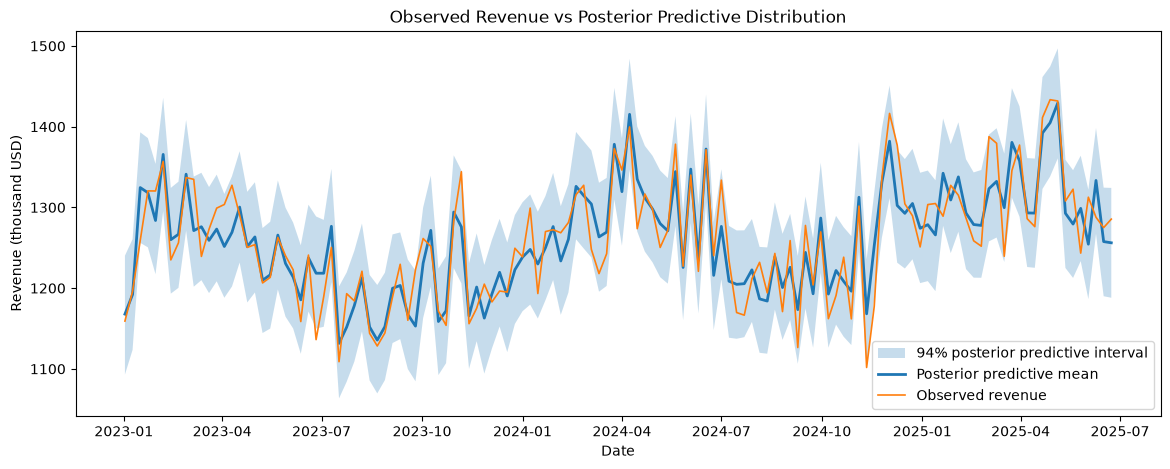

In [13]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.fill_between(
    dates,
    ppc_lower,
    ppc_upper,
    alpha=0.25,
    label="94% posterior predictive interval",
)

ax.plot(
    dates,
    ppc_mean,
    linewidth=2,
    label="Posterior predictive mean",
)

ax.plot(
    dates,
    observed,
    linewidth=1.2,
    label="Observed revenue",
)

ax.set(
    title="Observed Revenue vs Posterior Predictive Distribution",
    xlabel="Date",
    ylabel="Revenue (thousand USD)",
)

ax.legend()
plt.show()

In [14]:
rmse = np.sqrt(
    np.mean(
        (observed - ppc_mean) ** 2
    )
)

mae = np.mean(
    np.abs(
        observed - ppc_mean
    )
)

coverage_94 = np.mean(
    (observed >= ppc_lower)
    & (observed <= ppc_upper)
)

print(f"Training RMSE: {rmse:.2f}")
print(f"Training MAE: {mae:.2f}")
print(f"94% interval coverage: {coverage_94:.1%}")

Training RMSE: 32.27
Training MAE: 25.48
94% interval coverage: 96.9%


The model reproduces the training revenue patterns reasonably well, with prediction errors close to the synthetic observation-noise scale and slightly conservative uncertainty intervals.

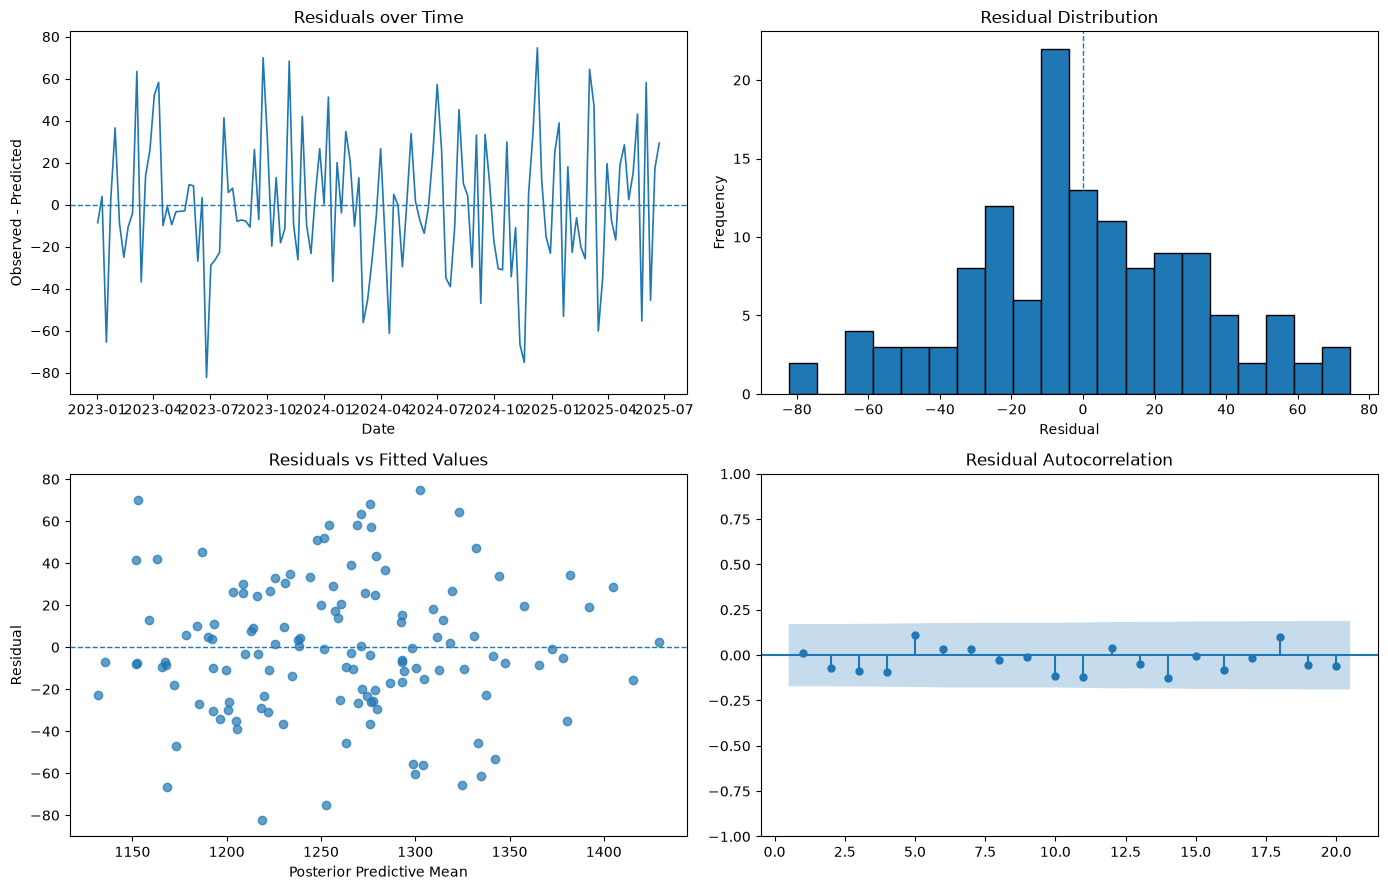

In [15]:
from statsmodels.graphics.tsaplots import plot_acf

residuals = observed - ppc_mean

fig, axes = plt.subplots(
    2,
    2,
    figsize=(14, 9),
)

# 1. Residuals over time
axes[0, 0].plot(
    dates,
    residuals,
    linewidth=1.2,
)

axes[0, 0].axhline(
    0,
    linestyle="--",
    linewidth=1,
)

axes[0, 0].set(
    title="Residuals over Time",
    xlabel="Date",
    ylabel="Observed - Predicted",
)

# 2. Residual histogram
axes[0, 1].hist(
    residuals,
    bins=20,
    edgecolor="black",
)

axes[0, 1].axvline(
    0,
    linestyle="--",
    linewidth=1,
)

axes[0, 1].set(
    title="Residual Distribution",
    xlabel="Residual",
    ylabel="Frequency",
)

# 3. Residuals versus fitted values
axes[1, 0].scatter(
    ppc_mean,
    residuals,
    alpha=0.7,
)

axes[1, 0].axhline(
    0,
    linestyle="--",
    linewidth=1,
)

axes[1, 0].set(
    title="Residuals vs Fitted Values",
    xlabel="Posterior Predictive Mean",
    ylabel="Residual",
)

# 4. Residual autocorrelation
plot_acf(
    residuals,
    lags=20,
    zero=False,
    ax=axes[1, 1],
)

axes[1, 1].set_title(
    "Residual Autocorrelation"
)

plt.tight_layout()
plt.show()

The residuals fluctuate randomly around zero, show no clear relationship with fitted values, and exhibit no statistically meaningful autocorrelation through lag 20. This suggests that the fitted model has captured most of the systematic temporal structure in the training data.

In [17]:
lag1_autocorrelation = np.corrcoef(
    residuals[:-1],
    residuals[1:],
)[0, 1]

print(
    f"Residual mean: "
    f"{residuals.mean():.2f}"
)

print(
    f"Residual SD: "
    f"{residuals.std(ddof=1):.2f}"
)

print(
    f"Lag-1 residual autocorrelation: "
    f"{lag1_autocorrelation:.3f}"
)

Residual mean: -0.09
Residual SD: 32.39
Lag-1 residual autocorrelation: 0.010


In [18]:
mmm_regularized.save(
    "../artifacts/mmm_regularized_with_ppc.nc"
)

print("Updated model with posterior predictive samples saved.")

Updated model with posterior predictive samples saved.
